# Video Diffusion Models: From Images to Moving Pictures

> **Difficulty:** Advanced | **Time:** ~50 min

You can generate a single image in seconds. Now multiply that by 60 frames, add temporal consistency, and try to fit it all in GPU memory. Welcome to video diffusion.

Video generation is one of the hardest problems in generative AI -- not because the theory is different from image diffusion, but because the **engineering constraints** change everything. This notebook analyzes:

1. Why adding a time dimension makes everything harder
2. Memory analysis: where the bytes go
3. Temporal attention architectures (factored, full 3D, windowed)
4. Architecture deep-dives: Sora, CogVideoX, HunyuanVideo
5. Progressive training strategies
6. The unsolved problem: temporal consistency

> **Note:** Video diffusion models require hundreds of GPUs to train and significant memory even for inference. This notebook focuses on **architecture analysis and calculations** that run on CPU.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import math

import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "../../..")))

from mp_tutorial.formatting import info_box
from mp_tutorial.plantuml import render_plantuml
import warnings
warnings.filterwarnings("ignore", message="Glyph.*missing from font", category=UserWarning)

---
## 1. Video as Temporal Extension of Images

An image is a 3D tensor: **H x W x C** (height, width, channels).

A video is a 4D tensor: **T x H x W x C** -- the same thing with an extra **time** dimension.

That single extra dimension changes everything about the computational cost:

| Data | Shape | Values (512x512, 4-ch latent) |
|------|-------|-------------------------------|
| 1 image | H x W x C | 512 x 512 x 4 = **1.05M** |
| 1 second (24 fps) | 24 x H x W x C | **25.2M** |
| 5 seconds (24 fps) | 120 x H x W x C | **125.8M** |
| 10 seconds (24 fps) | 240 x H x W x C | **251.7M** |

The raw data grows linearly with T. But the real problem is **attention**, which grows quadratically with sequence length.

In [2]:
# Video vs image: the numbers that matter
H, W, C = 512, 512, 4  # latent space (after VAE encoding)
fps = 24

print("=" * 65)
print(f"{'Data':<25} {'Frames':>7} {'Values':>12} {'MB (FP16)':>10}")
print("=" * 65)

for label, seconds in [("1 image", 1/fps), ("1 sec video", 1),
                        ("5 sec video", 5), ("10 sec video", 10),
                        ("1 min video", 60)]:
    frames = max(1, int(seconds * fps))
    values = frames * H * W * C
    mb = values * 2 / (1024**2)  # FP16 = 2 bytes
    print(f"{label:<25} {frames:>7,} {values:>12,} {mb:>9.1f}")

print("=" * 65)

info_box(
    "Video generation is fundamentally an image generation problem with an extra "
    "time dimension -- but that extra dimension changes everything about the engineering.",
    title="The Core Challenge"
)

Data                       Frames       Values  MB (FP16)
1 image                         1    1,048,576       2.0
1 sec video                    24   25,165,824      48.0
5 sec video                   120  125,829,120     240.0
10 sec video                  240  251,658,240     480.0
1 min video                 1,440 1,509,949,440    2880.0


---
## 2. Memory Analysis: Why Video Diffusion Is Hard

Raw tensor size is only part of the story. The real memory bottleneck is **self-attention**.

In a Transformer-based diffusion model:
1. The image/video is patchified into tokens
2. Self-attention computes pairwise interactions between **all** tokens
3. Attention memory scales as **O(N^2)** where N is the number of tokens

For images, N is manageable. For video, N explodes.

In [3]:
def video_memory_analysis(frames=60, height=512, width=512, channels=4,
                          latent_scale=8, patch_size=2, hidden_dim=1024,
                          n_heads=16, n_layers=24):
    # Latent dimensions (after VAE encoding)
    lat_t = frames
    lat_h = height // latent_scale
    lat_w = width // latent_scale
    print(f"Pixel space:  {frames} x {height} x {width} x 3")
    print(f"Latent space: {lat_t} x {lat_h} x {lat_w} x {channels}")

    # Patchification -> tokens
    n_spatial = (lat_h // patch_size) * (lat_w // patch_size)
    n_tokens = lat_t * n_spatial
    print(f"\nSpatial patches per frame: ({lat_h}//{patch_size}) x ({lat_w}//{patch_size}) = {n_spatial}")
    print(f"Total tokens: {lat_t} frames x {n_spatial} patches = {n_tokens:,}")

    # Attention memory (the bottleneck)
    attn_scores_bytes = n_tokens ** 2 * 2  # FP16
    attn_scores_gb = attn_scores_bytes / (1024**3)
    print(f"\n--- Self-Attention Memory (Full Attention) ---")
    print(f"Attention score matrix: {n_tokens:,} x {n_tokens:,} = {n_tokens**2:,.0f} entries")
    print(f"Memory per head: {attn_scores_gb:.2f} GB (FP16)")
    print(f"Memory all heads ({n_heads}): {attn_scores_gb * n_heads:.2f} GB")

    # KV cache per layer
    kv_per_layer = 2 * n_tokens * hidden_dim * 2  # K + V, FP16
    kv_total = kv_per_layer * n_layers
    kv_total_gb = kv_total / (1024**3)
    print(f"\n--- KV Cache ---")
    print(f"Per layer: {kv_per_layer / (1024**2):.1f} MB")
    print(f"All {n_layers} layers: {kv_total_gb:.2f} GB")

    # Activations (rough estimate)
    act_per_layer = n_tokens * hidden_dim * 4 * 2
    act_total_gb = act_per_layer * n_layers / (1024**3)
    print(f"\n--- Activations (estimate) ---")
    print(f"Per layer: {act_per_layer / (1024**2):.1f} MB")
    print(f"All layers: {act_total_gb:.2f} GB")

    total_gb = attn_scores_gb * n_heads + kv_total_gb + act_total_gb
    print(f"\n{'='*50}")
    print(f"TOTAL ESTIMATED MEMORY: {total_gb:.1f} GB")
    print(f"{'='*50}")
    return n_tokens, attn_scores_gb * n_heads, kv_total_gb, act_total_gb

# Image vs video comparison
print("IMAGE (1 frame, 512x512):")
print("-" * 50)
img_tokens, img_attn, img_kv, img_act = video_memory_analysis(frames=1)

print("\n\nVIDEO (60 frames, 512x512):")
print("-" * 50)
vid_tokens, vid_attn, vid_kv, vid_act = video_memory_analysis(frames=60)

print(f"\n\nScaling factor:")
print(f"  Tokens: {vid_tokens/img_tokens:.0f}x more")
print(f"  Attention memory: {vid_attn/max(img_attn, 1e-10):.0f}x more")

IMAGE (1 frame, 512x512):
--------------------------------------------------
Pixel space:  1 x 512 x 512 x 3
Latent space: 1 x 64 x 64 x 4

Spatial patches per frame: (64//2) x (64//2) = 1024
Total tokens: 1 frames x 1024 patches = 1,024

--- Self-Attention Memory (Full Attention) ---
Attention score matrix: 1,024 x 1,024 = 1,048,576 entries
Memory per head: 0.00 GB (FP16)
Memory all heads (16): 0.03 GB

--- KV Cache ---
Per layer: 4.0 MB
All 24 layers: 0.09 GB

--- Activations (estimate) ---
Per layer: 8.0 MB
All layers: 0.19 GB

TOTAL ESTIMATED MEMORY: 0.3 GB


VIDEO (60 frames, 512x512):
--------------------------------------------------
Pixel space:  60 x 512 x 512 x 3
Latent space: 60 x 64 x 64 x 4

Spatial patches per frame: (64//2) x (64//2) = 1024
Total tokens: 60 frames x 1024 patches = 61,440

--- Self-Attention Memory (Full Attention) ---
Attention score matrix: 61,440 x 61,440 = 3,774,873,600 entries
Memory per head: 7.03 GB (FP16)
Memory all heads (16): 112.50 GB

--- KV C

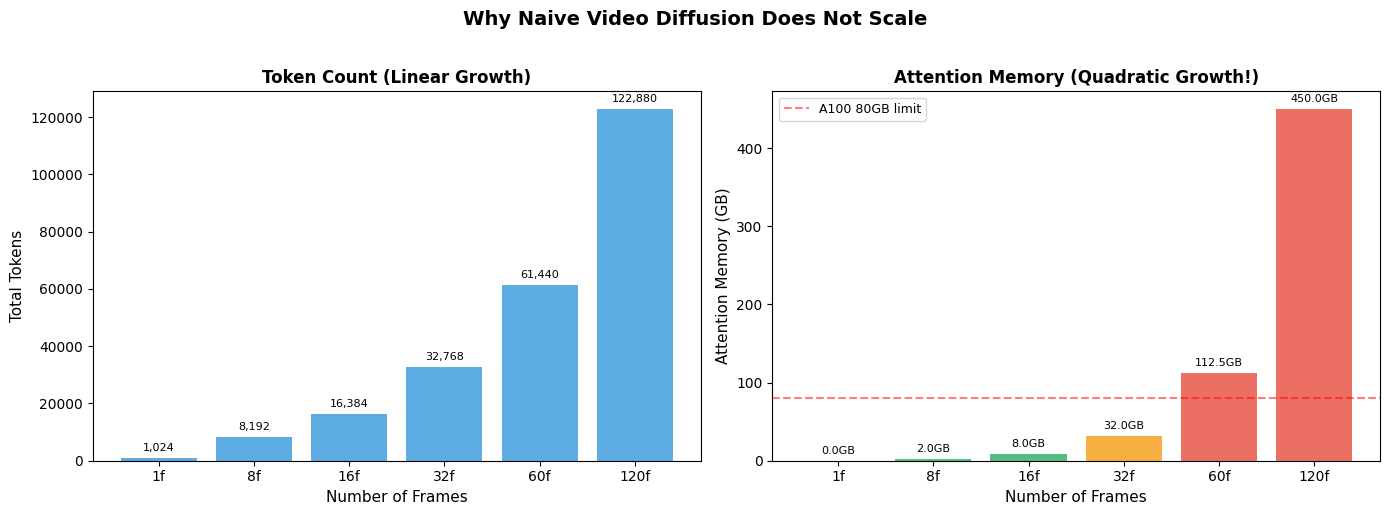

In [4]:
# Visualize the quadratic explosion
frames_list = [1, 8, 16, 32, 60, 120]
lat_h, lat_w = 64, 64  # 512/8
patch_size = 2
spatial_tokens = (lat_h // patch_size) * (lat_w // patch_size)

total_tokens = []
attn_memory_gb = []

for f in frames_list:
    n = f * spatial_tokens
    total_tokens.append(n)
    mem = (n ** 2) * 2 / (1024**3)  # FP16, single head
    attn_memory_gb.append(mem * 16)  # 16 heads

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Token count (linear)
axes[0].bar(range(len(frames_list)), total_tokens, color='#3498DB', alpha=0.8)
axes[0].set_xticks(range(len(frames_list)))
axes[0].set_xticklabels([f'{f}f' for f in frames_list])
axes[0].set_xlabel('Number of Frames', fontsize=11)
axes[0].set_ylabel('Total Tokens', fontsize=11)
axes[0].set_title('Token Count (Linear Growth)', fontsize=12, fontweight='bold')
for i, v in enumerate(total_tokens):
    axes[0].text(i, v + max(total_tokens)*0.02, f'{v:,}', ha='center', fontsize=8)

# Attention memory (quadratic)
colors = ['#27AE60' if m < 10 else '#F39C12' if m < 80 else '#E74C3C' for m in attn_memory_gb]
axes[1].bar(range(len(frames_list)), attn_memory_gb, color=colors, alpha=0.8)
axes[1].set_xticks(range(len(frames_list)))
axes[1].set_xticklabels([f'{f}f' for f in frames_list])
axes[1].set_xlabel('Number of Frames', fontsize=11)
axes[1].set_ylabel('Attention Memory (GB)', fontsize=11)
axes[1].set_title('Attention Memory (Quadratic Growth!)', fontsize=12, fontweight='bold')
axes[1].axhline(y=80, color='red', linestyle='--', alpha=0.5, label='A100 80GB limit')
axes[1].legend(fontsize=9)
for i, v in enumerate(attn_memory_gb):
    axes[1].text(i, v + max(attn_memory_gb)*0.02, f'{v:.1f}GB', ha='center', fontsize=8)

plt.suptitle('Why Naive Video Diffusion Does Not Scale', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

info_box(
    "This quadratic scaling is why naive video diffusion requires 100+ GB of GPU memory "
    "for even short clips. Every architecture in production uses some trick to avoid full "
    "spatiotemporal attention.",
    title="The Quadratic Wall"
)

---
## 3. Temporal Attention Architectures

The core question: how do we let video tokens attend to each other without O((T*H*W)^2) memory?

Three main approaches have emerged:

### Approach 1: Factored Attention (Spatial + Temporal)
- **Spatial attention**: each frame attends to itself independently (like image diffusion)
- **Temporal attention**: each spatial position attends across all frames
- Memory: **O(H^2 * W^2) + O(T^2)** instead of O(T^2 * H^2 * W^2)
- Used in: Video LDM, AnimateDiff, ModelScope

### Approach 2: Full 3D Attention
- Every token attends to every other token across space and time
- Memory: **O((T * H * W)^2)** -- most expensive but best quality
- Used in: Sora (with patchification to reduce token count)

### Approach 3: Windowed / Local Attention
- Each token attends only to nearby tokens in space and time
- Memory: **O(T * H * W * window_size)** -- linear in token count
- Used in: Some efficient video models, combined with sparse global attention

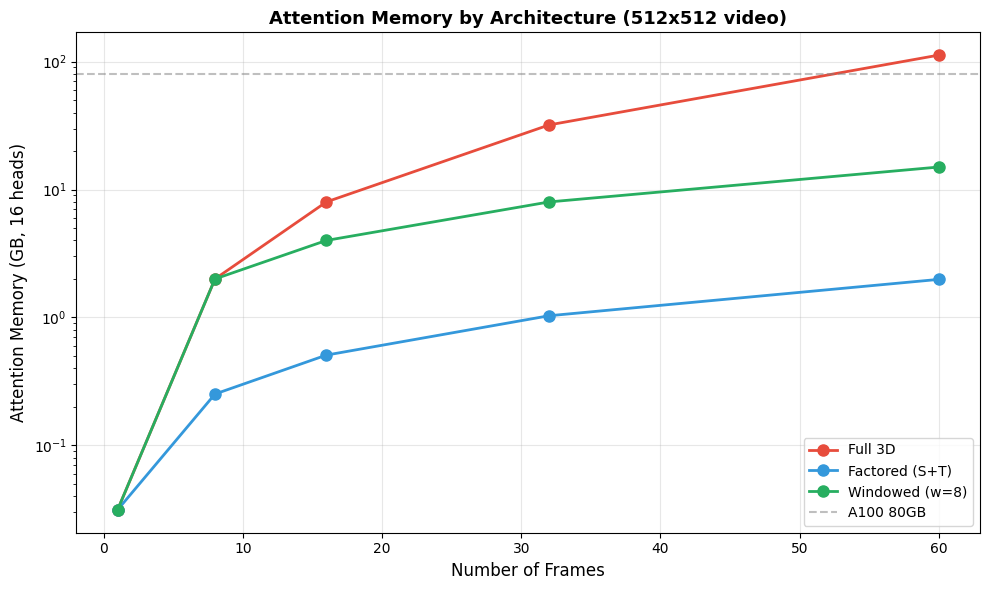

Frames               Full 3D      Factored (S+T)      Windowed (w=8)
--------------------------------------------------------------------
1                     0.03GB              0.03GB              0.03GB
8                     2.00GB              0.25GB              2.00GB
16                    8.00GB              0.51GB              4.00GB
32                   32.00GB              1.03GB              8.00GB
60                  112.50GB              1.98GB             15.00GB


In [5]:
def attention_memory(approach, T, H, W, bytes_per_entry=2):
    if approach == "full_3d":
        N = T * H * W
        return N * N * bytes_per_entry
    elif approach == "factored":
        spatial = T * (H * W) * (H * W) * bytes_per_entry
        temporal = (H * W) * T * T * bytes_per_entry
        return spatial + temporal
    elif approach == "windowed":
        window_t = min(8, T)
        N = T * H * W
        return N * window_t * H * W * bytes_per_entry
    else:
        raise ValueError(f"Unknown approach: {approach}")

# Parameters: 512x512 image, latent_scale=8, patch_size=2
H_patches = 512 // 8 // 2  # = 32
W_patches = H_patches       # = 32
n_heads = 16

frame_counts = [1, 8, 16, 32, 60]
approaches = ["full_3d", "factored", "windowed"]
labels = {"full_3d": "Full 3D", "factored": "Factored (S+T)", "windowed": "Windowed (w=8)"}
colors = {"full_3d": "#E74C3C", "factored": "#3498DB", "windowed": "#27AE60"}

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

for approach in approaches:
    mem_gb = []
    for T in frame_counts:
        mem = attention_memory(approach, T, H_patches, W_patches) * n_heads
        mem_gb.append(mem / (1024**3))
    ax.plot(frame_counts, mem_gb, 'o-', label=labels[approach],
            color=colors[approach], linewidth=2, markersize=8)

ax.axhline(y=80, color='gray', linestyle='--', alpha=0.5, label='A100 80GB')
ax.set_xlabel('Number of Frames', fontsize=12)
ax.set_ylabel('Attention Memory (GB, 16 heads)', fontsize=12)
ax.set_title('Attention Memory by Architecture (512x512 video)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_yscale('log')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print exact numbers
print(f"{'Frames':<8}", end="")
for a in approaches:
    print(f"{labels[a]:>20}", end="")
print()
print("-" * 68)
for T in frame_counts:
    print(f"{T:<8}", end="")
    for a in approaches:
        mem = attention_memory(a, T, H_patches, W_patches) * n_heads / (1024**3)
        print(f"{mem:>18.2f}GB", end="")
    print()

In [6]:
render_plantuml('''
skinparam backgroundColor white
skinparam defaultFontSize 13
skinparam shadowing false

title Factored Attention: Spatial + Temporal

rectangle "Input Video Tokens\n(T x H x W)" as input #LightBlue

rectangle "**Spatial Attention**\nEach frame attends to itself\nT independent attention ops\nMemory: O(H*W)^2 per frame" as spatial #LightGreen

rectangle "**Temporal Attention**\nEach position attends across frames\nH*W independent attention ops\nMemory: O(T^2) per position" as temporal #LightCoral

rectangle "Output Video Tokens\n(T x H x W)" as output #LightBlue

input --> spatial : "Reshape to\n(T*B, H*W, D)"
spatial --> temporal : "Reshape to\n(H*W*B, T, D)"
temporal --> output : "Reshape to\n(B, T*H*W, D)"

note right of spatial
  Frame 1 tokens attend to Frame 1 tokens
  Frame 2 tokens attend to Frame 2 tokens
  ...each frame is independent
end note

note right of temporal
  Position (0,0) attends across all T frames
  Position (0,1) attends across all T frames
  ...each position is independent
end note
''')

**PlantUML rendering failed** (not well-formed (invalid token): line 34, column 16). Source:
```
@startuml
skinparam backgroundColor white
skinparam defaultFontSize 13
skinparam shadowing false

title Factored Attention: Spatial + Temporal

rectangle "Input Video Tokens
(T x H x W)" as input #LightBlue

rectangle "**Spatial Attention**
Each frame attends to itself
T independent attention ops
Memory: O(H*W)^2 per frame" as spatial #LightGreen

rectangle "**Temporal Attention**
Each position attends across frames
H*W independent attention ops
Memory: O(T^2) per position" as temporal #LightCoral

rectangle "Output Video Tokens
(T x H x W)" as output #LightBlue

input --> spatial : "Reshape to
(T*B, H*W, D)"
spatial --> temporal : "Reshape to
(H*W*B, T, D)"
temporal --> output : "Reshape to
(B, T*H*W, D)"

note right of spatial
  Frame 1 tokens attend to Frame 1 tokens
  Frame 2 tokens attend to Frame 2 tokens
  ...each frame is independent
end note

note right of temporal
  Position (0,0) attends across all T frames
  Position (0,1) attends across all T frames
  ...each position is independent
end note
@enduml
```

---
## 4. Sora: Spacetime Patches and Full Attention

OpenAI's Sora (2024) demonstrated that scaling a DiT-like architecture with full spatiotemporal attention can produce remarkable video quality. The key ideas:

### Spacetime Patchification
Instead of 2D patches (p x p), Sora uses **3D patches** (t_p x h_p x w_p):
- A 2D patch merges spatial pixels: p x p pixels become 1 token
- A 3D patch merges space AND time: t_p frames x h_p x w_p pixels become 1 token
- This reduces the token count by a factor of t_p x h_p x w_p

### Architecture
- **3D VAE** compresses video into a spatiotemporal latent
- **Spacetime patchification** further reduces tokens
- **DiT backbone** with full spatiotemporal attention over all patches
- Variable resolution and duration through flexible positional embeddings

### Why it works
The 3D patchification reduces tokens enough that full attention becomes tractable. Instead of attending over T x H x W tokens, you attend over (T/t_p) x (H/h_p) x (W/w_p) tokens.

In [7]:
def spacetime_patch_analysis(frames=60, height=512, width=512,
                              latent_temporal_compress=4,
                              latent_spatial_compress=8,
                              channels=16,
                              patch_t=1, patch_h=2, patch_w=2,
                              hidden_dim=1024, n_heads=16):
    # After 3D VAE
    lat_t = frames // latent_temporal_compress
    lat_h = height // latent_spatial_compress
    lat_w = width // latent_spatial_compress
    print(f"After 3D VAE: {lat_t} x {lat_h} x {lat_w} x {channels}")

    # After spacetime patchification
    tok_t = lat_t // patch_t
    tok_h = lat_h // patch_h
    tok_w = lat_w // patch_w
    n_tokens = tok_t * tok_h * tok_w
    print(f"After patchify (p={patch_t}x{patch_h}x{patch_w}): "
          f"{tok_t} x {tok_h} x {tok_w} = {n_tokens:,} tokens")

    # Attention memory (full attention)
    attn_gb = n_tokens ** 2 * 2 * n_heads / (1024**3)
    print(f"Full attention memory ({n_heads} heads): {attn_gb:.2f} GB")
    return n_tokens, attn_gb

print("=== WITHOUT spacetime patches (image-style 2D patches) ===")
tok_naive, mem_naive = spacetime_patch_analysis(
    frames=60, patch_t=1, patch_h=2, patch_w=2,
    latent_temporal_compress=1
)

print("\n=== WITH 3D VAE temporal compression (4x) ===")
tok_vae, mem_vae = spacetime_patch_analysis(
    frames=60, patch_t=1, patch_h=2, patch_w=2,
    latent_temporal_compress=4
)

print("\n=== WITH 3D VAE + spacetime patches (2x2x2) ===")
tok_full, mem_full = spacetime_patch_analysis(
    frames=60, patch_t=2, patch_h=2, patch_w=2,
    latent_temporal_compress=4
)

print(f"\n--- Reduction Summary ---")
print(f"Naive tokens:      {tok_naive:>10,}  ->  Attention: {mem_naive:.2f} GB")
print(f"+ 3D VAE:          {tok_vae:>10,}  ->  Attention: {mem_vae:.2f} GB  "
      f"({tok_naive/tok_vae:.0f}x fewer tokens)")
print(f"+ Spacetime patch: {tok_full:>10,}  ->  Attention: {mem_full:.2f} GB  "
      f"({tok_naive/tok_full:.0f}x fewer tokens)")

info_box(
    "Sora's key insight: by patchifying in both space and time, the sequence length "
    "grows as O(T*H*W / p^3) instead of O(T*H*W), making full attention tractable "
    "for moderate video lengths.",
    title="Spacetime Patchification"
)

=== WITHOUT spacetime patches (image-style 2D patches) ===
After 3D VAE: 60 x 64 x 64 x 16
After patchify (p=1x2x2): 60 x 32 x 32 = 61,440 tokens
Full attention memory (16 heads): 112.50 GB

=== WITH 3D VAE temporal compression (4x) ===
After 3D VAE: 15 x 64 x 64 x 16
After patchify (p=1x2x2): 15 x 32 x 32 = 15,360 tokens
Full attention memory (16 heads): 7.03 GB

=== WITH 3D VAE + spacetime patches (2x2x2) ===
After 3D VAE: 15 x 64 x 64 x 16
After patchify (p=2x2x2): 7 x 32 x 32 = 7,168 tokens
Full attention memory (16 heads): 1.53 GB

--- Reduction Summary ---
Naive tokens:          61,440  ->  Attention: 112.50 GB
+ 3D VAE:              15,360  ->  Attention: 7.03 GB  (4x fewer tokens)
+ Spacetime patch:      7,168  ->  Attention: 1.53 GB  (9x fewer tokens)


In [8]:
render_plantuml('''
skinparam backgroundColor white
skinparam defaultFontSize 12
skinparam shadowing false

title Sora Architecture (Simplified)

rectangle "Raw Video\nT x H x W x 3" as raw #LightGray
rectangle "**3D VAE Encoder**\nSpatial: 8x compression\nTemporal: 4x compression" as vae_enc #LightBlue
rectangle "**Spacetime Patchify**\n3D patches (t x h x w)\n+ positional embedding" as patch #LightGreen
rectangle "**DiT Block 1**\nFull spatiotemporal attention\n+ AdaLN-Zero conditioning" as dit1 #PaleGreen
rectangle "**DiT Block 2**" as dit2 #PaleGreen
rectangle "..." as dots #PaleGreen
rectangle "**DiT Block N**" as ditN #PaleGreen
rectangle "**Unpatchify**\nReverse 3D patchification" as unpatch #LightGreen
rectangle "**3D VAE Decoder**" as vae_dec #LightBlue
rectangle "Generated Video\nT x H x W x 3" as output #LightGray

rectangle "**Conditioning**\nText (T5 encoder)\n+ Duration\n+ Resolution" as cond #Wheat

raw --> vae_enc
vae_enc --> patch
patch --> dit1
dit1 --> dit2
dit2 --> dots
dots --> ditN
ditN --> unpatch
unpatch --> vae_dec
vae_dec --> output

cond --> dit1
cond --> dit2
cond --> ditN
''')

**PlantUML rendering failed** (not well-formed (invalid token): line 34, column 16). Source:
```
@startuml
skinparam backgroundColor white
skinparam defaultFontSize 12
skinparam shadowing false

title Sora Architecture (Simplified)

rectangle "Raw Video
T x H x W x 3" as raw #LightGray
rectangle "**3D VAE Encoder**
Spatial: 8x compression
Temporal: 4x compression" as vae_enc #LightBlue
rectangle "**Spacetime Patchify**
3D patches (t x h x w)
+ positional embedding" as patch #LightGreen
rectangle "**DiT Block 1**
Full spatiotemporal attention
+ AdaLN-Zero conditioning" as dit1 #PaleGreen
rectangle "**DiT Block 2**" as dit2 #PaleGreen
rectangle "..." as dots #PaleGreen
rectangle "**DiT Block N**" as ditN #PaleGreen
rectangle "**Unpatchify**
Reverse 3D patchification" as unpatch #LightGreen
rectangle "**3D VAE Decoder**" as vae_dec #LightBlue
rectangle "Generated Video
T x H x W x 3" as output #LightGray

rectangle "**Conditioning**
Text (T5 encoder)
+ Duration
+ Resolution" as cond #Wheat

raw --> vae_enc
vae_enc --> patch
patch --> dit1
dit1 --> dit2
dit2 --> dots
dots --> ditN
ditN --> unpatch
unpatch --> vae_dec
vae_dec --> output

cond --> dit1
cond --> dit2
cond --> ditN
@enduml
```

---
## 5. CogVideoX: Expert Transformers for Video

CogVideoX (Zhipu AI, 2024) takes a different approach from Sora, using several innovations:

### Key Ideas

1. **3D Causal VAE**: Compresses video in both space (8x8) and time (4x), with causal temporal convolutions so each frame can only see past frames during encoding.

2. **Expert Adaptive LayerNorm**: Instead of standard AdaLN, uses a learned routing mechanism to apply different normalization parameters for text tokens vs. video tokens. This helps the model treat text conditioning and video generation differently.

3. **Full Attention with Interleaved Text**: Text tokens are concatenated with video tokens in the sequence, and full attention is applied over the joint sequence. No separate cross-attention layer needed.

4. **Progressive Training**: Images first, then short clips, then longer clips. Each stage initializes from the previous one.

In [9]:
# CogVideoX: Expert Adaptive LayerNorm concept
class ExpertAdaLN(nn.Module):
    """Simplified Expert Adaptive LayerNorm from CogVideoX.

    Uses different modulation parameters for text vs video tokens,
    allowing the model to process each modality differently.
    """
    def __init__(self, hidden_dim, cond_dim):
        super().__init__()
        self.norm = nn.LayerNorm(hidden_dim, elementwise_affine=False)
        # Separate experts for text and video
        self.text_expert = nn.Sequential(nn.SiLU(), nn.Linear(cond_dim, 3 * hidden_dim))
        self.video_expert = nn.Sequential(nn.SiLU(), nn.Linear(cond_dim, 3 * hidden_dim))

    def forward(self, x, cond, text_mask):
        """
        x: (B, N, D) - joint text+video tokens
        cond: (B, D_cond) - timestep conditioning
        text_mask: (B, N) - True for text tokens, False for video tokens
        """
        x_norm = self.norm(x)
        text_params = self.text_expert(cond).unsqueeze(1)
        video_params = self.video_expert(cond).unsqueeze(1)

        # Select expert based on token type
        mask = text_mask.unsqueeze(-1).float()
        params = mask * text_params + (1 - mask) * video_params

        gamma, beta, alpha = params.chunk(3, dim=-1)
        x_mod = (1 + gamma) * x_norm + beta
        return x_mod, alpha

# Demo
torch.manual_seed(42)
expert_adaln = ExpertAdaLN(hidden_dim=256, cond_dim=512)

B, N_text, N_video, D = 2, 77, 256, 256
x = torch.randn(B, N_text + N_video, D)
cond = torch.randn(B, 512)
text_mask = torch.zeros(B, N_text + N_video, dtype=torch.bool)
text_mask[:, :N_text] = True

x_mod, alpha = expert_adaln(x, cond, text_mask)
print(f"Joint sequence: {N_text} text + {N_video} video = {N_text + N_video} tokens")
print(f"Input:  {list(x.shape)}")
print(f"Output: {list(x_mod.shape)}")
print(f"\nText tokens get different scale/shift than video tokens,")
print(f"even though they share the same attention layer.")

params_single = sum(p.numel() for p in nn.Sequential(nn.SiLU(), nn.Linear(512, 3*256)).parameters())
params_expert = sum(p.numel() for p in expert_adaln.parameters()) - sum(p.numel() for p in expert_adaln.norm.parameters())
print(f"\nSingle AdaLN params: {params_single:,}")
print(f"Expert AdaLN params: {params_expert:,} ({params_expert/params_single:.1f}x)")

Joint sequence: 77 text + 256 video = 333 tokens
Input:  [2, 333, 256]
Output: [2, 333, 256]

Text tokens get different scale/shift than video tokens,
even though they share the same attention layer.

Single AdaLN params: 393,984
Expert AdaLN params: 787,968 (2.0x)


---
## 6. HunyuanVideo: Dual-Stream to Single-Stream

HunyuanVideo (Tencent, 2024) introduces a hybrid architecture that balances quality with efficiency:

### Key Innovations

1. **Dual-Stream to Single-Stream Design**:
   - **First half** of the network: text and video tokens are processed in **separate streams** (dual-stream), each with their own self-attention. Only lightweight cross-information is shared.
   - **Second half**: text and video tokens are **merged into a single stream** with full joint attention.
   - Rationale: early layers learn modality-specific features; later layers need cross-modal interaction.

2. **Causal 3D VAE**: 4x temporal + 8x8 spatial compression, with causal temporal convolutions.

3. **MLLM Text Encoder**: Uses a multimodal large language model (not just CLIP) for richer text understanding. This gives better instruction-following for complex prompts.

4. **Flow Matching**: Uses rectified flow instead of DDPM-style noise scheduling.

In [10]:
# HunyuanVideo: Dual-stream to Single-stream analysis
def hunyuan_architecture_analysis(n_layers=40, switch_layer=20,
                                   n_text_tokens=256, n_video_tokens=4096,
                                   hidden_dim=3072, n_heads=24):
    N_t = n_text_tokens
    N_v = n_video_tokens

    print(f"Text tokens:  {N_t}")
    print(f"Video tokens: {N_v}")
    print(f"Hidden dim:   {hidden_dim}")
    print(f"Total layers: {n_layers} (switch at layer {switch_layer})")
    print()

    # Dual-stream: separate attention for text and video
    dual_attn_text = N_t * N_t * 2 * n_heads
    dual_attn_video = N_v * N_v * 2 * n_heads
    dual_total = dual_attn_text + dual_attn_video

    # Single-stream: joint attention over all tokens
    N_joint = N_t + N_v
    single_attn = N_joint * N_joint * 2 * n_heads

    # Totals
    full_single = single_attn * n_layers
    hybrid = dual_total * switch_layer + single_attn * (n_layers - switch_layer)
    full_dual = dual_total * n_layers

    print("--- Attention Memory Per Layer ---")
    print(f"Dual-stream:   text {dual_attn_text/(1024**2):.1f} MB + "
          f"video {dual_attn_video/(1024**2):.1f} MB = {dual_total/(1024**2):.1f} MB")
    print(f"Single-stream: joint {single_attn/(1024**2):.1f} MB")
    ratio = single_attn / dual_total
    print(f"Single is {ratio:.1f}x more expensive per layer")

    print(f"\n--- Total Attention Memory (all layers) ---")
    print(f"All dual-stream:   {full_dual/(1024**3):.2f} GB")
    print(f"All single-stream: {full_single/(1024**3):.2f} GB")
    print(f"HunyuanVideo hybrid ({switch_layer}+{n_layers-switch_layer}): "
          f"{hybrid/(1024**3):.2f} GB")
    saving = (1 - hybrid / full_single) * 100
    print(f"Hybrid saves {saving:.0f}% vs all single-stream")

    return full_dual, full_single, hybrid

full_dual, full_single, hybrid = hunyuan_architecture_analysis()

info_box(
    "HunyuanVideo uses a dual-stream design where text and video tokens are processed "
    "separately first, then merged. This balances quality with efficiency -- early layers "
    "learn modality-specific features cheaply, while later layers get the expensive but "
    "powerful cross-modal attention.",
    title="Dual-Stream to Single-Stream"
)

Text tokens:  256
Video tokens: 4096
Hidden dim:   3072
Total layers: 40 (switch at layer 20)

--- Attention Memory Per Layer ---
Dual-stream:   text 3.0 MB + video 768.0 MB = 771.0 MB
Single-stream: joint 867.0 MB
Single is 1.1x more expensive per layer

--- Total Attention Memory (all layers) ---
All dual-stream:   30.12 GB
All single-stream: 33.87 GB
HunyuanVideo hybrid (20+20): 31.99 GB
Hybrid saves 6% vs all single-stream


In [11]:
render_plantuml('''
skinparam backgroundColor white
skinparam defaultFontSize 12
skinparam shadowing false

title HunyuanVideo: Dual-Stream to Single-Stream

rectangle "Video Frames" as vid_in #LightGray
rectangle "Text Prompt" as txt_in #LightGray

rectangle "**Causal 3D VAE**\n4x temporal\n8x8 spatial" as vae #LightBlue
rectangle "**MLLM Text Encoder**\n(not just CLIP)" as text_enc #Wheat

rectangle "Video Tokens" as vid_tok #LightCoral
rectangle "Text Tokens" as txt_tok #LightGreen

vid_in --> vae
txt_in --> text_enc
vae --> vid_tok
text_enc --> txt_tok

package "Dual-Stream Layers (1 to L/2)" {
  rectangle "Video Self-Attention" as vid_attn #LightCoral
  rectangle "Text Self-Attention" as txt_attn #LightGreen
}

vid_tok --> vid_attn
txt_tok --> txt_attn

rectangle "**Merge Streams**\nConcatenate tokens" as merge #LightYellow

vid_attn --> merge
txt_attn --> merge

package "Single-Stream Layers (L/2+1 to L)" {
  rectangle "**Joint Attention**\nAll tokens attend to all tokens\n(text + video)" as joint #Orchid
}

merge --> joint

rectangle "**Unpatchify + 3D VAE Decoder**" as decode #LightBlue
rectangle "Generated Video" as output #LightGray

joint --> decode
decode --> output
''')

**PlantUML rendering failed** (not well-formed (invalid token): line 34, column 16). Source:
```
@startuml
skinparam backgroundColor white
skinparam defaultFontSize 12
skinparam shadowing false

title HunyuanVideo: Dual-Stream to Single-Stream

rectangle "Video Frames" as vid_in #LightGray
rectangle "Text Prompt" as txt_in #LightGray

rectangle "**Causal 3D VAE**
4x temporal
8x8 spatial" as vae #LightBlue
rectangle "**MLLM Text Encoder**
(not just CLIP)" as text_enc #Wheat

rectangle "Video Tokens" as vid_tok #LightCoral
rectangle "Text Tokens" as txt_tok #LightGreen

vid_in --> vae
txt_in --> text_enc
vae --> vid_tok
text_enc --> txt_tok

package "Dual-Stream Layers (1 to L/2)" {
  rectangle "Video Self-Attention" as vid_attn #LightCoral
  rectangle "Text Self-Attention" as txt_attn #LightGreen
}

vid_tok --> vid_attn
txt_tok --> txt_attn

rectangle "**Merge Streams**
Concatenate tokens" as merge #LightYellow

vid_attn --> merge
txt_attn --> merge

package "Single-Stream Layers (L/2+1 to L)" {
  rectangle "**Joint Attention**
All tokens attend to all tokens
(text + video)" as joint #Orchid
}

merge --> joint

rectangle "**Unpatchify + 3D VAE Decoder**" as decode #LightBlue
rectangle "Generated Video" as output #LightGray

joint --> decode
decode --> output
@enduml
```

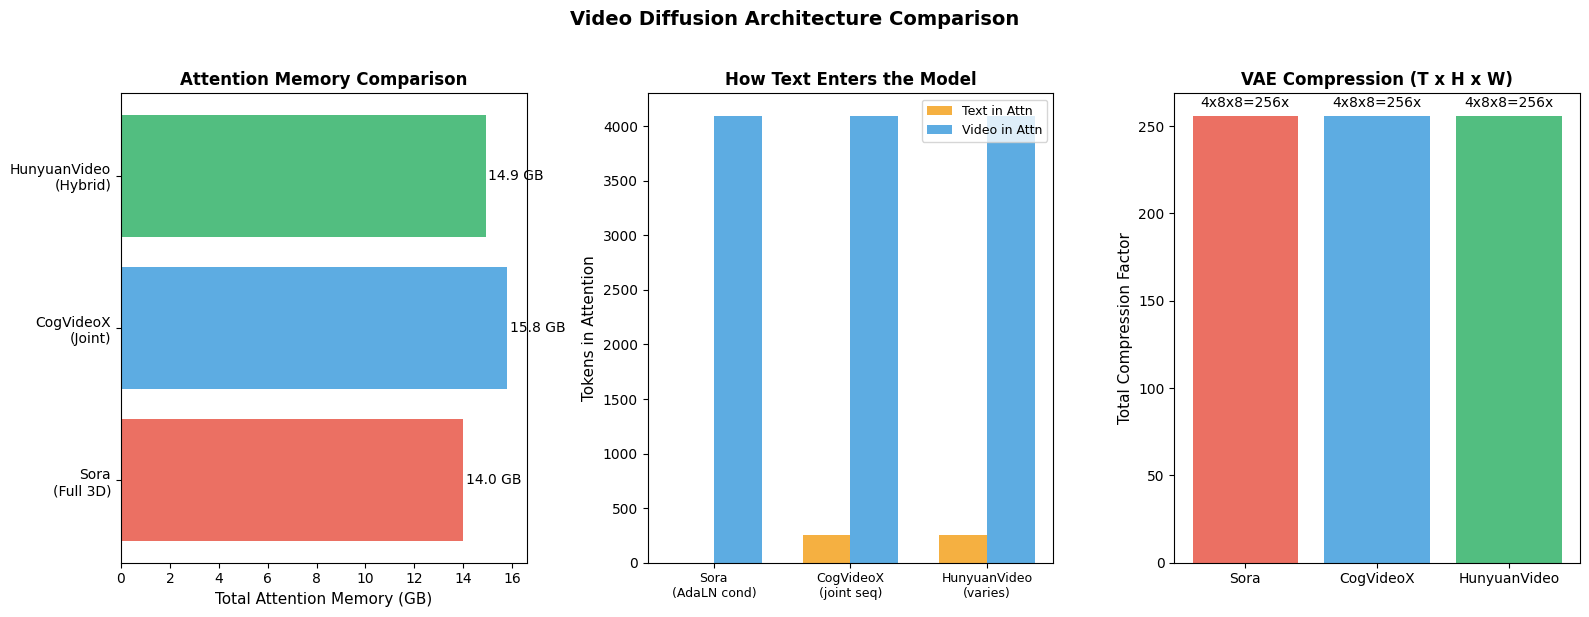

In [12]:
# Side-by-side comparison of all three architectures
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

N_text = 256
N_video = 4096
n_heads = 16
n_layers = 28

def calc_mem(n_q, n_kv, heads=n_heads):
    return n_q * n_kv * 2 * heads / (1024**3)

# Bar chart: total attention memory
sora_mem = calc_mem(N_video, N_video) * n_layers
cog_mem = calc_mem(N_text + N_video, N_text + N_video) * n_layers
hunyu_dual = (calc_mem(N_video, N_video) + calc_mem(N_text, N_text)) * 14
hunyu_single = calc_mem(N_text + N_video, N_text + N_video) * 14
hunyu_mem = hunyu_dual + hunyu_single

names = ['Sora\n(Full 3D)', 'CogVideoX\n(Joint)', 'HunyuanVideo\n(Hybrid)']
total_mem = [sora_mem, cog_mem, hunyu_mem]
bar_colors = ['#E74C3C', '#3498DB', '#27AE60']

axes[0].barh(names, total_mem, color=bar_colors, alpha=0.8)
axes[0].set_xlabel("Total Attention Memory (GB)", fontsize=11)
axes[0].set_title("Attention Memory Comparison", fontsize=12, fontweight='bold')
for i, v in enumerate(total_mem):
    axes[0].text(v + 0.1, i, f"{v:.1f} GB", va='center', fontsize=10)

# How text enters the model
x = np.arange(3)
width = 0.35
axes[1].bar(x - width/2, [0, N_text, N_text], width, label='Text in Attn', color='#F39C12', alpha=0.8)
axes[1].bar(x + width/2, [N_video, N_video, N_video], width, label='Video in Attn', color='#3498DB', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Sora\n(AdaLN cond)', 'CogVideoX\n(joint seq)', 'HunyuanVideo\n(varies)'], fontsize=9)
axes[1].set_ylabel('Tokens in Attention', fontsize=11)
axes[1].set_title('How Text Enters the Model', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)

# VAE compression comparison
models_c = ['Sora', 'CogVideoX', 'HunyuanVideo']
temporal_compress = [4, 4, 4]
spatial_compress = [8, 8, 8]
total_compress = [t * s * s for t, s in zip(temporal_compress, spatial_compress)]

axes[2].bar(models_c, total_compress, color=['#E74C3C', '#3498DB', '#27AE60'], alpha=0.8)
axes[2].set_ylabel('Total Compression Factor', fontsize=11)
axes[2].set_title('VAE Compression (T x H x W)', fontsize=12, fontweight='bold')
for i, v in enumerate(total_compress):
    t, s = temporal_compress[i], spatial_compress[i]
    axes[2].text(i, v + 5, f'{t}x{s}x{s}={v}x', ha='center', fontsize=10)

plt.suptitle('Video Diffusion Architecture Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 7. Progressive Training Strategy

Training a video diffusion model from scratch on long, high-resolution video is prohibitively expensive. Every major video model uses **progressive training**:

| Stage | Data | Resolution | Frames | Purpose |
|-------|------|-----------|--------|---------|
| 1 | Images | 256x256 | 1 | Learn spatial generation (leverage pretrained image models) |
| 2 | Short clips | 256x256 | 8-16 | Learn basic motion |
| 3 | Medium clips | 512x512 | 32-64 | Learn longer motion + higher resolution |
| 4 | Long clips | 720p+ | 64-128+ | Learn complex motion + high quality |

Each stage initializes from the previous stage's checkpoint. This lets the model reuse what it has already learned.

Stage                         Tokens   Attn/layer  Batch    Effective
                                             (MB)   size       tokens
Stage 1: Images                  256        2.0    256       65,536
Stage 2: Short clips           1,024       32.0     32       32,768
Stage 3: Medium clips         12,288     4608.0      4       49,152
Stage 4: Long clips          108,000   355957.0      1      108,000


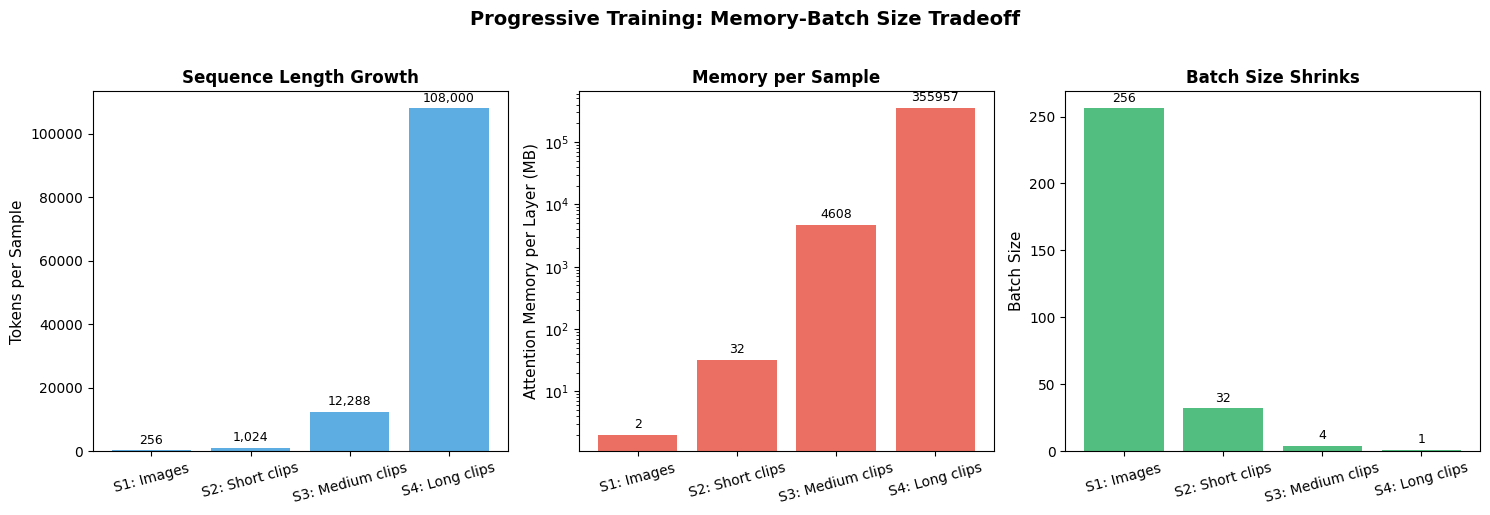


Cross-reference: Distributed training of video models uses the parallelism strategies from
Data Parallelism (../../en/01-data-parallelism.ipynb) and
Sequence Parallelism (../../en/04-sequence-parallelism.ipynb)


In [13]:
def progressive_training_analysis():
    stages = [
        {"name": "Stage 1: Images", "frames": 1, "height": 256, "width": 256, "batch_size": 256},
        {"name": "Stage 2: Short clips", "frames": 16, "height": 256, "width": 256, "batch_size": 32},
        {"name": "Stage 3: Medium clips", "frames": 48, "height": 512, "width": 512, "batch_size": 4},
        {"name": "Stage 4: Long clips", "frames": 120, "height": 720, "width": 1280, "batch_size": 1},
    ]

    latent_scale = 8
    temporal_compress = 4
    patch_size = 2
    n_heads = 16
    n_layers = 28

    print(f"{'Stage':<25} {'Tokens':>10} {'Attn/layer':>12} {'Batch':>6} {'Effective':>12}")
    print(f"{'':25} {'':>10} {'(MB)':>12} {'size':>6} {'tokens':>12}")
    print("=" * 72)

    stage_data = []
    for s in stages:
        t = max(1, s["frames"] // temporal_compress)
        h = s["height"] // latent_scale // patch_size
        w = s["width"] // latent_scale // patch_size
        tokens = t * h * w
        attn_mb = tokens ** 2 * 2 * n_heads / (1024**2)
        eff_tokens = tokens * s["batch_size"]
        print(f"{s['name']:<25} {tokens:>10,} {attn_mb:>10.1f} {s['batch_size']:>6} {eff_tokens:>12,}")
        stage_data.append({"name": s["name"], "tokens": tokens, "attn_mb": attn_mb,
                           "batch_size": s["batch_size"]})

    return stage_data

stage_data = progressive_training_analysis()

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

names = [s["name"].replace("Stage ", "S") for s in stage_data]
tokens = [s["tokens"] for s in stage_data]
attn_mb = [s["attn_mb"] for s in stage_data]
batch_sizes = [s["batch_size"] for s in stage_data]

axes[0].bar(names, tokens, color='#3498DB', alpha=0.8)
axes[0].set_ylabel('Tokens per Sample', fontsize=11)
axes[0].set_title('Sequence Length Growth', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(tokens):
    axes[0].text(i, v + max(tokens)*0.02, f'{v:,}', ha='center', fontsize=9)

axes[1].bar(names, attn_mb, color='#E74C3C', alpha=0.8)
axes[1].set_ylabel('Attention Memory per Layer (MB)', fontsize=11)
axes[1].set_title('Memory per Sample', fontsize=12, fontweight='bold')
axes[1].set_yscale('log')
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(attn_mb):
    axes[1].text(i, v * 1.3, f'{v:.0f}', ha='center', fontsize=9)

axes[2].bar(names, batch_sizes, color='#27AE60', alpha=0.8)
axes[2].set_ylabel('Batch Size', fontsize=11)
axes[2].set_title('Batch Size Shrinks', fontsize=12, fontweight='bold')
axes[2].tick_params(axis='x', rotation=15)
for i, v in enumerate(batch_sizes):
    axes[2].text(i, v + max(batch_sizes)*0.02, str(v), ha='center', fontsize=9)

plt.suptitle('Progressive Training: Memory-Batch Size Tradeoff', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

info_box(
    "Progressive training lets you reuse image generation knowledge. Most video models "
    "start from a pretrained image model and gradually learn temporal dynamics.",
    title="Why Progressive?"
)
print("\nCross-reference: Distributed training of video models uses the parallelism strategies from")
print("Data Parallelism (../../en/01-data-parallelism.ipynb) and")
print("Sequence Parallelism (../../en/04-sequence-parallelism.ipynb)")

---
## 8. Temporal Consistency: The Hardest Unsolved Problem

Generating individual frames is one thing. Making them **consistent** across time is fundamentally harder:

- **Object permanence**: a person's face should look the same in frame 1 and frame 60
- **Motion coherence**: camera movements should be smooth, not jerky
- **Physics**: objects should obey gravity, momentum, and collision
- **Temporal flickering**: the most common artifact -- textures and details that change randomly between frames

### Techniques for Consistency

| Technique | How it works | Tradeoff |
|-----------|-------------|----------|
| **Temporal attention** | Let each frame see nearby frames | More memory, better coherence |
| **Frame conditioning** | Condition on previous frames during generation | Sequential, slower |
| **Motion modules** | Separate modules that learn motion patterns | Added parameters |
| **Temporal super-resolution** | Generate keyframes, then interpolate | Lower quality between keyframes |
| **Post-processing** | Optical flow + blending to reduce flicker | Adds inference cost |

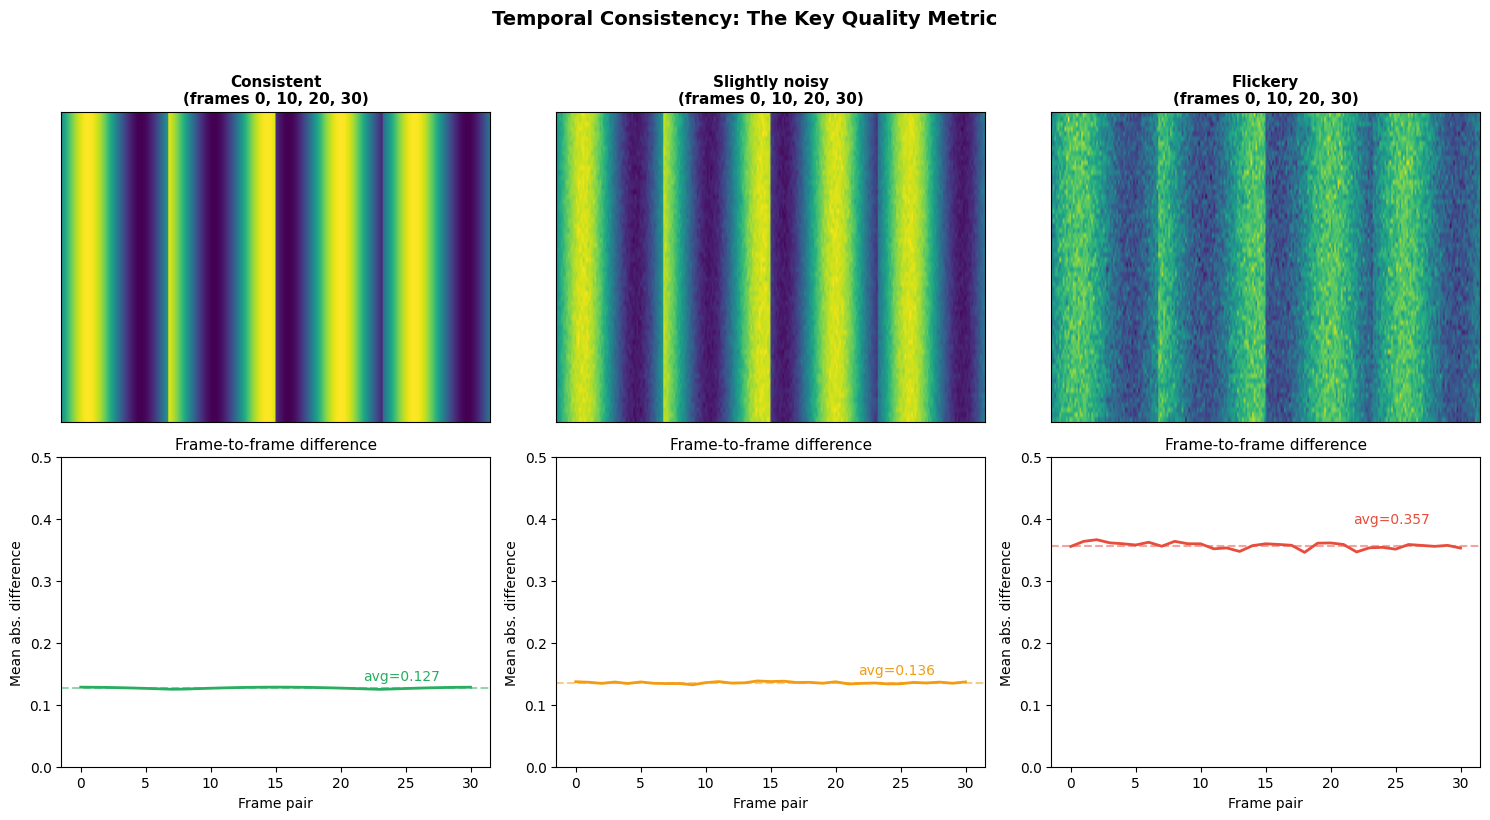

In [14]:
# Temporal consistency: measuring how much adjacent frames differ
torch.manual_seed(42)
T, H, W = 32, 64, 64

# Simulate three quality levels
perfect = torch.zeros(T, 1, H, W)
for t in range(T):
    x_shift = t * 2
    for i in range(H):
        perfect[t, 0, i, :] = torch.sin(torch.arange(W, dtype=torch.float32) * 0.1 + x_shift * 0.1)

good = perfect + torch.randn_like(perfect) * 0.05
flickery = perfect + torch.randn_like(perfect) * 0.3

def temporal_diff(video):
    diffs = []
    for t in range(1, len(video)):
        diff = (video[t] - video[t-1]).abs().mean().item()
        diffs.append(diff)
    return diffs

perfect_diffs = temporal_diff(perfect)
good_diffs = temporal_diff(good)
flickery_diffs = temporal_diff(flickery)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Top row: show frames
for col, (name, video) in enumerate([("Consistent", perfect),
                                      ("Slightly noisy", good),
                                      ("Flickery", flickery)]):
    frames_to_show = [0, 10, 20, 30]
    combined = torch.cat([video[f, 0] for f in frames_to_show], dim=1)
    axes[0, col].imshow(combined.numpy(), cmap='viridis', aspect='auto')
    axes[0, col].set_title(f'{name}\n(frames 0, 10, 20, 30)', fontsize=11, fontweight='bold')
    axes[0, col].set_xticks([])
    axes[0, col].set_yticks([])

# Bottom row: temporal difference
for col, (name, diffs, color) in enumerate([
    ("Consistent", perfect_diffs, "#27AE60"),
    ("Slightly noisy", good_diffs, "#F39C12"),
    ("Flickery", flickery_diffs, "#E74C3C")
]):
    axes[1, col].plot(diffs, color=color, linewidth=2)
    axes[1, col].set_xlabel('Frame pair', fontsize=10)
    axes[1, col].set_ylabel('Mean abs. difference', fontsize=10)
    axes[1, col].set_title('Frame-to-frame difference', fontsize=11)
    axes[1, col].set_ylim(0, max(max(flickery_diffs) * 1.1, 0.5))
    avg = np.mean(diffs)
    axes[1, col].axhline(y=avg, color=color, linestyle='--', alpha=0.5)
    axes[1, col].text(len(diffs)*0.7, avg*1.1, f'avg={avg:.3f}', fontsize=10, color=color)

plt.suptitle('Temporal Consistency: The Key Quality Metric', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

info_box(
    "Temporal flickering is the #1 quality issue in deployed video generation systems. "
    "Production pipelines often include post-processing stages (optical flow warping, "
    "temporal smoothing) specifically to reduce it.",
    title="Flickering in Production"
)

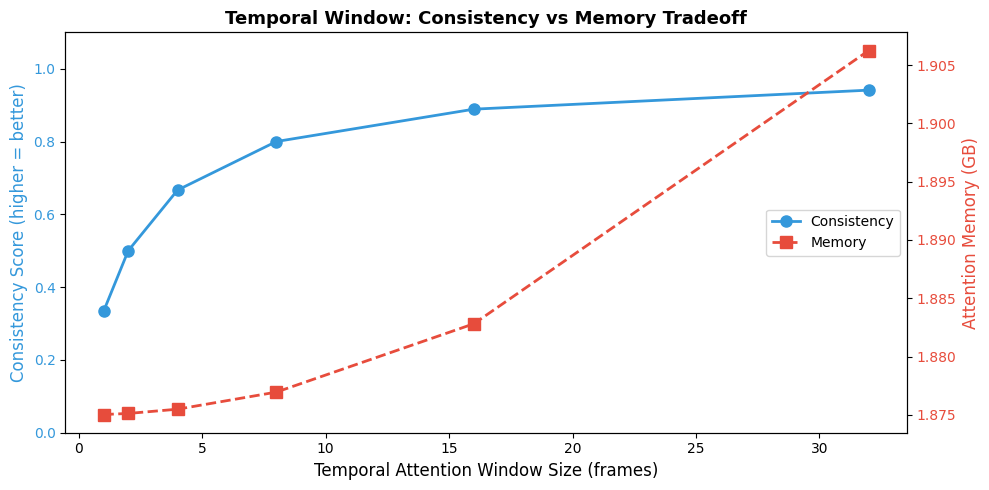

Key insight: consistency improves quickly with small windows (4-8 frames),
but memory cost keeps growing. Most models use window sizes of 4-16 frames
as a practical compromise.


In [15]:
# Temporal attention window size vs consistency vs cost
window_sizes = [1, 2, 4, 8, 16, 32]
T = 60
H_patches = 32
W_patches = 32
spatial = H_patches * W_patches
n_heads = 16

consistency_score = []
memory_gb = []

for w in window_sizes:
    effective_window = min(w, T)
    temp_attn_mem = spatial * (effective_window ** 2) * 2 * n_heads
    spatial_attn_mem = T * (spatial ** 2) * 2 * n_heads
    total_mem = (temp_attn_mem + spatial_attn_mem) / (1024**3)
    memory_gb.append(total_mem)
    consistency_score.append(1 - 1.0 / (1 + 0.5 * effective_window))

fig, ax1 = plt.subplots(figsize=(10, 5))

color1 = '#3498DB'
color2 = '#E74C3C'

ax1.set_xlabel('Temporal Attention Window Size (frames)', fontsize=12)
ax1.set_ylabel('Consistency Score (higher = better)', fontsize=12, color=color1)
ax1.plot(window_sizes, consistency_score, 'o-', color=color1, linewidth=2, markersize=8, label='Consistency')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_ylim(0, 1.1)

ax2 = ax1.twinx()
ax2.set_ylabel('Attention Memory (GB)', fontsize=12, color=color2)
ax2.plot(window_sizes, memory_gb, 's--', color=color2, linewidth=2, markersize=8, label='Memory')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Temporal Window: Consistency vs Memory Tradeoff', fontsize=13, fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right', fontsize=10)
plt.tight_layout()
plt.show()

print("Key insight: consistency improves quickly with small windows (4-8 frames),")
print("but memory cost keeps growing. Most models use window sizes of 4-16 frames")
print("as a practical compromise.")

---
## 9. Summary

| Concept | Key Takeaway |
|---------|-------------|
| **Video = Image + Time** | Adding T frames multiplies data linearly but attention **quadratically** |
| **Factored Attention** | Separate spatial and temporal attention: O(HW)^2 + O(T^2) instead of O(THW)^2 |
| **Sora** | 3D spacetime patches + full DiT attention; reduces tokens via 3D patchification |
| **CogVideoX** | Expert Adaptive LayerNorm for text/video; joint attention over concatenated tokens |
| **HunyuanVideo** | Dual-stream (cheap) then single-stream (expressive); MLLM text encoder |
| **Progressive Training** | Image -> short video -> long video; each stage builds on the last |
| **Temporal Consistency** | The hardest unsolved problem; temporal attention helps but does not fully solve it |

### Key Papers
- **Sora**: [Video generation models as world simulators (OpenAI, 2024)](https://openai.com/research/video-generation-models-as-world-simulators)
- **CogVideoX**: [CogVideoX: Text-to-Video Diffusion Models with An Expert Transformer (2024)](https://arxiv.org/abs/2408.06072)
- **HunyuanVideo**: [HunyuanVideo: A Systematic Framework For Large Video Generative Models (2024)](https://arxiv.org/abs/2412.03603)

### Connections to Parallelism
Video models are among the most compute-intensive AI systems. Training them requires combining:
- [Data Parallelism](../../en/01-data-parallelism.ipynb) -- replicate the model across GPUs, split the batch
- [Sequence Parallelism](../../en/04-sequence-parallelism.ipynb) -- split the long token sequence across GPUs (essential for video)
- [Pipeline Parallelism](../../en/03-pipeline-parallelism.ipynb) -- split DiT layers across GPUs

### Next: [06-training-engineering.ipynb](06-training-engineering.ipynb) -- Engineering practices for training large diffusion models